In [46]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [49]:
class TicTacToe:
    def minimax_strategy(self, state, maximizing_player):
        def evaluate_board(board):
            #Kolla om den nuvarande spelaren eller motståndaren har vunnit.
            for player in ['X', 'O']:
                for i in range(3):
                    if all(board[i][j] == player for j in range(3)) or all(board[j][i] == player for j in range(3)):
                        return 1 if player == maximizing_player else -1

                if all(board[i][i] == player for i in range(3)) or all(board[i][2-i] == player for i in range(3)):
                    return 1 if player == maximizing_player else -1

            #Kolla om det är oavgjort.
            if all(cell != ' ' for row in board for cell in row):
                return 0

            #Spelet pågår fortfarande.
            return None

        def minimax(board, depth, is_maximizing):
            #Utvärdera brädet för att avgöra om det finns en vinnare eller om det är oavgjort.
            score = evaluate_board(board)

            if score is not None:
                return score

            if is_maximizing:
                #Maximera poängen om det är den maximaliserande spelarens tur.
                best_score = float('-inf')
                for i in range(3):
                    for j in range(3):
                        if board[i][j] == ' ':
                            #Gör ett drag och beräkna poängen för nästa tillstånd.
                            board[i][j] = maximizing_player
                            score = minimax(board, depth + 1, False)
                            #Ångra draget för att återställa brädet.
                            board[i][j] = ' '
                            #Uppdatera bästa poängen för att maximera.
                            best_score = max(score, best_score)
                return best_score
            else:
                #Minimera poängen om det är den minimiserande spelarens tur.
                best_score = float('inf')
                for i in range(3):
                    for j in range(3):
                        if board[i][j] == ' ':
                            #Gör ett drag och beräkna poängen för nästa tillstånd.
                            board[i][j] = 'O' if maximizing_player == 'X' else 'X'
                            score = minimax(board, depth + 1, True)
                            #Ångra draget för att återställa brädet.
                            board[i][j] = ' '
                            #Uppdatera bästa poängen för att minimera.
                            best_score = min(score, best_score)
                return best_score
        #Bästa draget och dess associerade poäng.
        best_move = None
        best_score = float('-inf')

        #Hitta det bästa draget med minimax algoritmen.
        for i in range(3):
            for j in range(3):
                if state[i][j] == ' ':
                    state[i][j] = maximizing_player
                    score = minimax(state, 0, False)
                    state[i][j] = ' '

                    if score > best_score:
                        best_score = score
                        best_move = (i, j)

        return best_move
    
    

    def __init__(self):
         #Q-tabell för att lagra Qvärden för varje state-action-par.
        self.q_table = {}    #Qtabell för att lagra Q-värden.
        self.alpha = 0.5    #Inlärningshastighet.
        self.gamma = 0.9    #Rabatt faktor.
        self.epsilon = 0.4    #Epsilon greedy för utforskning.
        self.training_results = {'epochs': [], 'win_rate_random': [], 'win_rate_minimax': []}
        

    def create_board(self):
        #Initialisera en tom Tic Tac Toe-bräda.
        return [[' ' for _ in range(3)] for _ in range(3)]    #Skapa en tom spelplan.
  
    
    def display_board(self, board):
        #Visa det aktuella tillståndet för Tic Tac Toe-brädet.
        for row in board:
            print('|'.join(row))    #Skriv ut varje rad med vertikala linjer mellan cellerna.
            print('-' * 5)    #Skriv ut en horisontell linje efter varje rad.
       
            
    def is_board_full(self, board):
        #Kolla om varje cell på spelplanen är upptagen.
        return all(cell != ' ' for row in board for cell in row)

    
    def make_move(self, board, row, col, player):
        #Gör ett drag på Tic Tac Toe-brädet om den valda positionen är tom.
        if board[row][col] == ' ':
            board[row][col] = player    #Om cellen är tom, gör draget.
            return True
        return False    #Om cellen är upptagen, returnera False.


    def check_winner(self, board, player):
        #Kolla om den angivna spelaren har vunnit spelet.
        for i in range(3):
            if all(board[i][j] == player for j in range(3)):
                print(f"Player {player} wins in row {i}")
                return True

            if all(board[j][i] == player for j in range(3)):
                print(f"Player {player} wins in column {i}")
                return True

        if all(board[i][i] == player for i in range(3)):
            print(f"Player {player} wins diagonally from top-left to bottom-right")
            return True

        if all(board[i][2-i] == player for i in range(3)):
            print(f"Player {player} wins diagonally from top-right to bottom-left")
            return True

        return False

    
    def available_moves(self, board):
        #Hämta en lista över tillgängliga tomma positioner på Tic Tac Toe-brädet.
        return [(i, j) for i in range(3) for j in range(3) if board[i][j] == ' ']

    
    def get_q_value(self, state, action):
        #Hämta Qvärdet för ett specifikt state actionpar från Qtabellen.
        state_tuple = tuple(map(tuple, state))

        if state_tuple not in self.q_table:
            #Initialisera Qvärden för alla tillgängliga drag i det aktuella tillståndet.
            self.q_table[state_tuple] = {action: 0.0 for action in self.available_moves(state)}
        else:
            #Se till att Qvärden initialiseras för nya tillgängliga drag i det aktuella tillståndet.
            for a in self.available_moves(state):
                if a not in self.q_table[state_tuple]:
                    self.q_table[state_tuple][a] = 0.0

        return self.q_table[state_tuple][action]


    def update_q_value(self, state, action, reward, next_state):
        #Uppdatera Qvärdet för ett state action par baserat på belöningen och Qvärdet för nästa tillstånd.
        max_next_q = max(self.get_q_value(next_state, next_action) for next_action in self.available_moves(next_state))
        current_q = self.get_q_value(state, action)
        new_q = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)
        self.q_table[tuple(map(tuple, state))][action] = new_q

   
     
    def train_policy(self, iterations):
        #Träna Qlearning policyn under flera iterationer.
        for epoch in range(iterations):
            print(f"Training Epoch: {epoch}")
            state = self.create_board()
            while not self.is_board_full(state):
                if random.random() < self.epsilon:
                    #Välj ett slumpmässigt drag med sannolikhet epsilon.
                    action = random.choice(self.available_moves(state))
                else:
                    #Välj draget med högsta Qvärde.
                    action = max(self.available_moves(state), key=lambda a: self.get_q_value(state, a))

                row, col = action
                player = 'X'
                self.make_move(state, row, col, player)

                if self.check_winner(state, player):
                    self.update_q_value(state, action, 1, state)
                    break

                if self.is_board_full(state):
                    self.update_q_value(state, action, 0, state)
                    break

                #Använd minimax strategi för spelaren 'O'.
                player = 'O'
                minimax_action = self.minimax_strategy(state, player)

                #Kontrollera om minimax-draget är giltigt.
                if minimax_action in self.available_moves(state):
                    self.make_move(state, *minimax_action, player)

                    if self.check_winner(state, player):
                        self.update_q_value(state, minimax_action, -1, state)
                        break

                state = [['X' if cell == 'X' else 'O' for cell in row] for row in state]

            #Utvärdera och registrera resultat efter varje epok.
            win_rate_random, win_rate_minimax = self.evaluate_policy()
            self.training_results['epochs'].append(epoch)
            self.training_results['win_rate_random'].append(win_rate_random)
            self.training_results['win_rate_minimax'].append(win_rate_minimax)

        print(self.training_results)


    
    def evaluate_policy(self):
        #Utvärdera policyn mot slumpmässiga och minimax-spelare.
        print("Evaluating Policy...")
        total_wins_random = 0
        total_wins_minimax = 0
        total_games = 100

        for _ in range(total_games):
            state = self.create_board().copy()

            while not self.is_board_full(state):
                #Policyns drag, antar 'X' spelare.
                action = self.policy(state)
                row, col = action
                player = 'X'
                self.make_move(state, row, col, player)

                if self.check_winner(state, player):
                    total_wins_random += 1
                    break

                if self.is_board_full(state):
                    break

                #Byt spelare till 'O' för nästa drag.
                player = 'O'
                random_action = random.choice(self.available_moves(state))
                if random_action is not None:
                    self.make_move(state, *random_action, player)

                    if self.check_winner(state, player):
                        total_wins_random += 1
                        break

                    if self.is_board_full(state):
                        break

            #Använd minimax strategi för spelaren 'O'.
            player = 'O'
            minimax_action = self.minimax_strategy(state, player)
            if minimax_action is not None:
                self.make_move(state, *minimax_action, player)

                if self.check_winner(state, player):
                    total_wins_minimax += 1

        win_rate_random = total_wins_random / total_games
        win_rate_minimax = total_wins_minimax / total_games

        return win_rate_random, win_rate_minimax
    

    
    def test_policy(self, policy):
        #Testa policyn mot slumpmässiga och minimax spelare.
        print("Testing Policy...")
        total_wins_random = 0
        total_wins_minimax = 0
        total_games = 100

        for _ in range(total_games):
            state = self.create_board()
            while not self.is_board_full(state):
                action = policy(state)
                row, col = action
                player = 'X'
                self.make_move(state, row, col, player)

                if self.check_winner(state, player):
                    total_wins_random += 1
                    break

                if self.is_board_full(state):
                    break

                #Byt spelare till 'O' för nästa drag.
                player = 'O'
                random_action = random.choice(self.available_moves(state))
                if random_action is not None:
                    self.make_move(state, *random_action, player)

                    if self.check_winner(state, player):
                        total_wins_random += 1
                        break

                    if self.is_board_full(state):
                        break

            #Använd minimax-strategi för spelaren 'O'.
            player = 'O'
            minimax_action = self.minimax_strategy(state, player)
            if minimax_action is not None:
                self.make_move(state, *minimax_action, player)

                if self.check_winner(state, player):
                    total_wins_minimax += 1

        win_rate_random = total_wins_random / total_games
        win_rate_minimax = total_wins_minimax / total_games

        print(f"Win rate against random player: {win_rate_random}")
        print(f"Win rate against minimax player: {win_rate_minimax}")
        
        
        
    def policy(self, state):
        #Välj åtgärden med det högsta Q-värdet som policyns drag.
        return max(self.available_moves(state), key=lambda a: self.get_q_value(state, a))

In [50]:
tic_tac_toe = TicTacToe()
tic_tac_toe.train_policy(100)  #Träna policyn.
print(tic_tac_toe.training_results)

Training Epoch: 0
Evaluating Policy...
Player X wins in row 0
Player O wins in row 1
Player O wins diagonally from top-right to bottom-left
Player O wins diagonally from top-right to bottom-left
Player O wins in column 2
Player O wins in row 2
Player X wins in column 0
Player X wins in row 0
Player X wins in column 0
Player O wins diagonally from top-right to bottom-left
Player O wins in row 2
Player X wins in row 0
Player X wins in column 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player O wins in row 1
Player X wins in row 0
Player O wins in row 1
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player O wins in row 1
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins diagonally from top-left to bottom-right
Player X wins in row 0
Player O wins diagonally from top-right to bottom-left
Player O wins diagonally from top-right to bottom-left
Player X wins in row 0
Player O wins in row 

Evaluating Policy...
Player X wins in row 0
Player X wins in row 0
Player X wins diagonally from top-left to bottom-right
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player O wins in column 2
Player O wins in row 2
Player X wins in row 0
Player X wins in column 2
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player O wins in row 1
Player X wins in column 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player O wins in column 2
Player O wins in column 2
Player O wins diagonally from top-right to bottom-left
Player O wins in row 2
Player X wins in row 0
Player X wins in row 0
Player O wins in row 1
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player O wins in column 1
Player O wins in column 1
Player X wins in row 0
Player O wins in column 1
Player O wins in column 1
Player X wins in row 0
Player O wins in column 2
Player O wins in row 2
Player X wi

Evaluating Policy...
Player X wins in row 0
Player X wins in row 0
Player O wins in row 1
Player X wins in row 0
Player O wins in column 2
Player O wins in row 2
Player X wins in column 0
Player X wins in row 0
Player X wins in row 0
Player O wins diagonally from top-right to bottom-left
Player O wins in row 2
Player X wins in column 0
Player X wins diagonally from top-left to bottom-right
Player X wins in row 0
Player X wins diagonally from top-left to bottom-right
Player X wins in row 0
Player X wins in row 0
Player O wins in row 1
Player O wins in column 2
Player O wins in column 2
Player X wins in column 0
Player O wins in column 1
Player X wins in row 0
Player O wins in column 2
Player O wins in column 2
Player X wins in row 0
Player O wins in column 1
Player O wins in column 1
Player O wins in column 2
Player O wins in row 2
Player O wins in row 2
Player O wins in row 2
Player X wins in row 0
Player X wins in row 0
Player O wins in column 2
Player O wins in column 2
Player O wins

Evaluating Policy...
Player O wins in row 2
Player O wins in row 2
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player O wins in row 1
Player X wins diagonally from top-right to bottom-left
Player X wins in row 0
Player O wins in row 1
Player X wins in column 2
Player X wins in row 0
Player O wins in row 1
Player X wins in row 0
Player X wins in row 0
Player X wins in column 0
Player X wins in row 0
Player X wins in row 0
Player O wins in row 1
Player O wins diagonally from top-right to bottom-left
Player O wins diagonally from top-right to bottom-left
Player X wins in row 0
Player X wins diagonally from top-left to bottom-right
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player O wins in row 1
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player O wins in column 2
Player O wins in row 2
Player X wins in row 0
Player O wins in row 2
Player O wins 

Evaluating Policy...
Player O wins diagonally from top-right to bottom-left
Player O wins diagonally from top-right to bottom-left
Player X wins in row 0
Player O wins in row 2
Player O wins in row 2
Player X wins in row 0
Player O wins in row 2
Player O wins in row 2
Player X wins diagonally from top-left to bottom-right
Player O wins in column 2
Player O wins in row 2
Player O wins in column 2
Player O wins in row 2
Player X wins in row 0
Player X wins in row 0
Player O wins in row 1
Player X wins in row 0
Player O wins diagonally from top-right to bottom-left
Player O wins in row 2
Player X wins in row 0
Player O wins diagonally from top-right to bottom-left
Player O wins in row 2
Player O wins in column 2
Player O wins in row 2
Player O wins diagonally from top-right to bottom-left
Player O wins diagonally from top-right to bottom-left
Player X wins in row 0
Player O wins in row 1
Player X wins in row 0
Player X wins in row 0
Player O wins in row 1
Player O wins diagonally from top

...

Evaluating Policy...
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in column 0
Player X wins in row 0
Player X wins diagonally from top-left to bottom-right
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins diagonally from top-right to bottom-left
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player O wins diagonally from top-right to bottom-left
Player O wins diagonally from top-right to bottom-left
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player O wins in row 1
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in column 0
Player O wins in column 1
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins 

Evaluating Policy...
Player X wins in row 0
Player O wins in row 1
Player X wins in row 0
Player O wins in column 2
Player O wins in row 2
Player X wins in row 0
Player O wins in row 1
Player X wins in row 0
Player X wins in row 0
Player X wins diagonally from top-left to bottom-right
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in column 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player O wins diagonally from top-right to bottom-left
Player O wins diagonally from top-right to bottom-left
Player O wins diagonally from top-right to bottom-left
Player O wins in row 2
Player O wins in column 1
Player O wins in column 1
Player O wins in column 2
Player O wins in row 2
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in column 0
Player O wins diagonally from top-right to bottom-left
Player O wins in row 2
Player X wins diago

Evaluating Policy...
Player X wins in row 0
Player O wins in row 1
Player X wins in column 0
Player X wins in row 0
Player X wins in row 0
Player O wins in row 2
Player O wins in row 2
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player O wins in row 1
Player X wins in column 1
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins diagonally from top-left to bottom-right
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player O wins in row 1
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player O wins diagonally from top-right to bottom-left
Player O wins diagonally from top-right to bottom-left
Player O wins in row 2
Player O wins in row 2
Player X wins in column 0
Player X wins in row 0
Player X wins in row 0
Player O wins in row 1
Player O wins in column 2
Player O wins in row 2
Player X wins in row 0
Player O wins in column 1
Player O wins in 

Evaluating Policy...
Player O wins diagonally from top-right to bottom-left
Player O wins diagonally from top-right to bottom-left
Player X wins in row 0
Player O wins in row 2
Player O wins in row 2
Player X wins in row 0
Player X wins in row 0
Player O wins in row 1
Player O wins in row 2
Player O wins in row 2
Player O wins in column 2
Player O wins in column 2
Player O wins in row 2
Player O wins in row 2
Player X wins in row 0
Player X wins in row 0
Player X wins in column 0
Player X wins in row 0
Player X wins diagonally from top-left to bottom-right
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player O wins in row 1
Player X wins in row 0
Player O wins in row 1
Player X wins in row 0
Player O wins in row 1
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player O wins in row 2
Player O wins in row 2
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player O wins in column

Evaluating Policy...
Player X wins in column 0
Player X wins in row 0
Player X wins in column 0
Player X wins in row 0
Player O wins in row 1
Player X wins in row 0
Player O wins in row 1
Player X wins in row 0
Player O wins in row 1
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins diagonally from top-right to bottom-left
Player X wins in row 0
Player O wins in row 1
Player X wins in row 0
Player X wins in row 0
Player O wins in row 1
Player X wins in row 0
Player O wins in column 2
Player O wins in column 2
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player O wins in row 1
Player O wins in row 2
Player O wins in row 2
Player O wins in column 2
Player O wins in row 2
Player X wins in row 0
Player X wins diagonally from top-left to bottom-right
Player O wins in column 2
Player O wins in column 2
Player X wins in row 0
Player X wins in row 0
Player X wins in row

In [29]:
#Testa den inlärda policyn mot en slumpmässig spelare.
tic_tac_toe.test_policy(tic_tac_toe.policy)

Testing Policy...
Player O wins in row 2
Player O wins in row 2
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player O wins in row 1
Player O wins diagonally from top-right to bottom-left
Player O wins diagonally from top-right to bottom-left
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player O wins in column 2
Player O wins in row 2
Player X wins in row 0
Player O wins in row 1
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player O wins in column 2
Player O wins in row 2
Player O wins in column 1
Player O wins in column 1
Player X wins in row 0
Player O wins in row 1
Player X wins diagonally from top-left to bottom-right
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in row 0
Player X wins in column 0
Player X wins in row 0
Player O wins in col

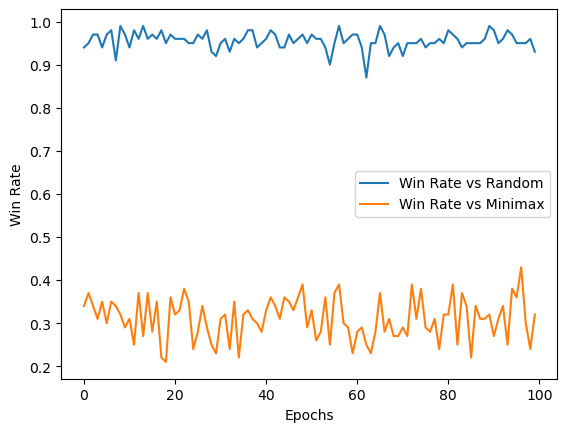

In [31]:
#Efter träningen är klar.
#Skapa och visa linjediagram över vinstfrekvensen mot slumpmässig spelare och minimax-spelare över träningsomgångarna.
plt.plot(tic_tac_toe.training_results['epochs'], tic_tac_toe.training_results['win_rate_random'], label='Win Rate vs Random')
plt.plot(tic_tac_toe.training_results['epochs'], tic_tac_toe.training_results['win_rate_minimax'], label='Win Rate vs Minimax')
plt.xlabel('Epochs')
plt.ylabel('Win Rate')
plt.legend()
plt.show()